In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
# Load raw data as pandas dataframes
calendar = pd.read_csv('../data/raw/calendar.csv')
sales_eval = pd.read_csv('../data/raw/sales_train_evaluation.csv')
sales_val = pd.read_csv('../data/raw/sales_train_validation.csv')
sell_prices = pd.read_csv('../data/raw/sell_prices.csv')

In [3]:
print('CALENDAR')
print('==========================================================')
print(calendar.info())
print('\nSALES TRAIN EVALUATION')
print('==========================================================')
print(sales_eval.info())
print('\nSALES TRAIN VALIDATION')
print('==========================================================')
print(sales_val.info())
print('==========================================================')
print('\nSALES PRICES')
print(sell_prices.info())

CALENDAR
<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB
None

SALES TRAIN EVALUATION
<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 452.9 MB
None

SALE

In [4]:
print(calendar.shape)
calendar.head()

(1969, 14)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [5]:
print(sell_prices.shape)
sell_prices.head()

(6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [6]:
print(sales_eval.shape)
sales_eval.head()

(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


#### The sales_eval table will be converted from wide to long format to enable advanced visualization and simplify filtering and grouping. Long format tables also make joining and modeling easier. 




In [7]:
# wide format to long format
sales_melted = pd.melt(sales_eval, 
                       id_vars =['id', 'item_id', 'dept_id','cat_id','store_id','state_id'], # colmuns that will not be changed
                       # the rest of the columns will be melted
                       var_name = 'days', # name of the new melted column
                       value_name = 'sales' # sales per day
                      )  

In [8]:
sales_melted.head(10) 

,id,item_id,dept_id,cat_id,store_id,state_id,days,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
5,HOBBIES_1_006_CA_1_evaluation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
6,HOBBIES_1_007_CA_1_evaluation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
7,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_1,12
8,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,d_1,2
9,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [9]:
# renaming calendar column d to days to merge tables
calendar.rename(columns={'d':'days'}, inplace = True)
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,days,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [10]:
# merging long format sales data with calendar
df = pd.merge(sales_melted, calendar, on ='days', how = 'left')
df.head(2)

,id,item_id,dept_id,cat_id,store_id,state_id,days,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [11]:
merged_df = pd.merge(df, sell_prices, on =['store_id', 'item_id','wm_yr_wk'], how = 'left')
merged_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,days,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


In [12]:
#overall summary
merged_df[['sales', 'sell_price']].describe()

,sales,sell_price
count,5.918109e+07,4.688168e+07
mean,1.130888e+00,4.409438e+00
std,3.870038e+00,3.406106e+00
min,0.000000e+00,1.000000e-02
25%,0.000000e+00,2.180000e+00
50%,0.000000e+00,3.470000e+00
75%,1.000000e+00,5.840000e+00
max,7.630000e+02,1.073200e+02


In [13]:
# sales by category department 
merged_df.groupby('cat_id')['sales'].agg(['mean','median','std','sum','max'])

,mean,median,std,sum,max
cat_id,,,,,
FOODS,1.646427,0.0,5.144377,45922427,763
HOBBIES,0.569058,0.0,2.036739,6240656,294
HOUSEHOLD,0.726498,0.0,2.087060,14764090,626


In [14]:
# Min, max, and spread of prices per category
merged_df.groupby('cat_id')['sell_price'].agg(['min', 'max', 'mean', 'median', 'std'])

,min,max,mean,median,std
cat_id,,,,,
FOODS,0.01,19.48,3.248950,2.68,2.130764
HOBBIES,0.01,30.98,5.329613,3.97,4.821907
HOUSEHOLD,0.01,107.32,5.465685,4.94,3.373758


In [15]:
sns.set_theme(palette = 'muted', font_scale = 1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [16]:
total_sales = merged_df.groupby('date')['sales'].sum()  # grouping by sum to get total sales

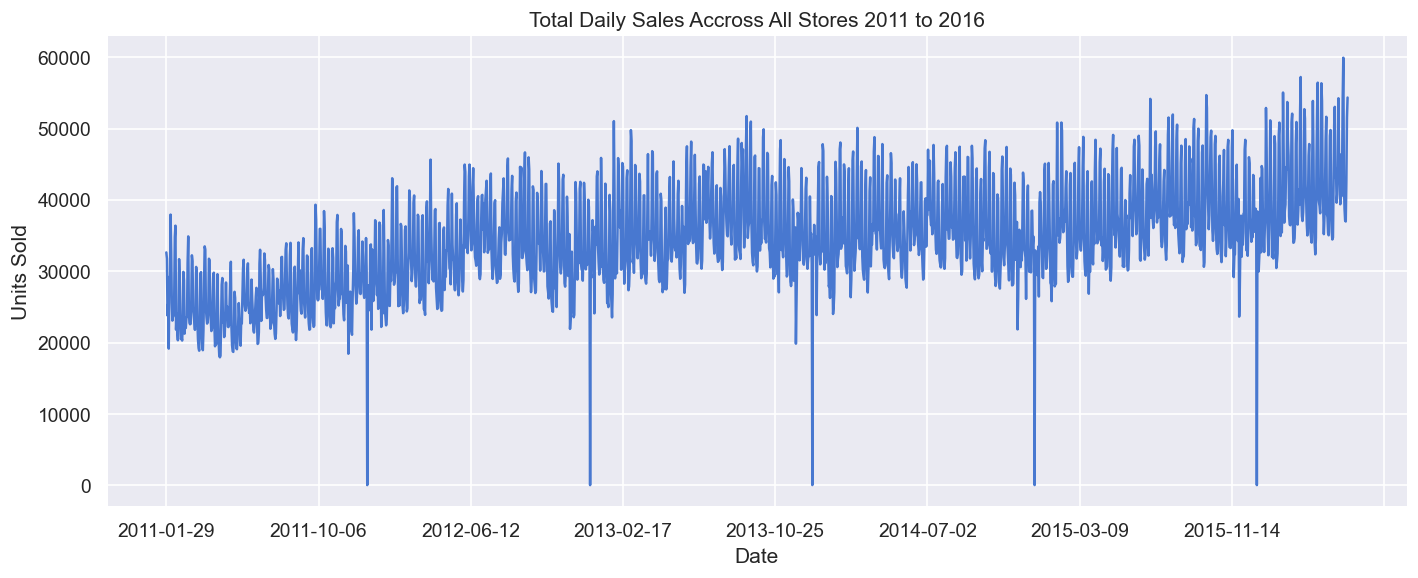

In [17]:
plt.figure(figsize = (12,5))
total_sales.plot(ax=plt.gca())
plt.title('Total Daily Sales Accross All Stores 2011 to 2016')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

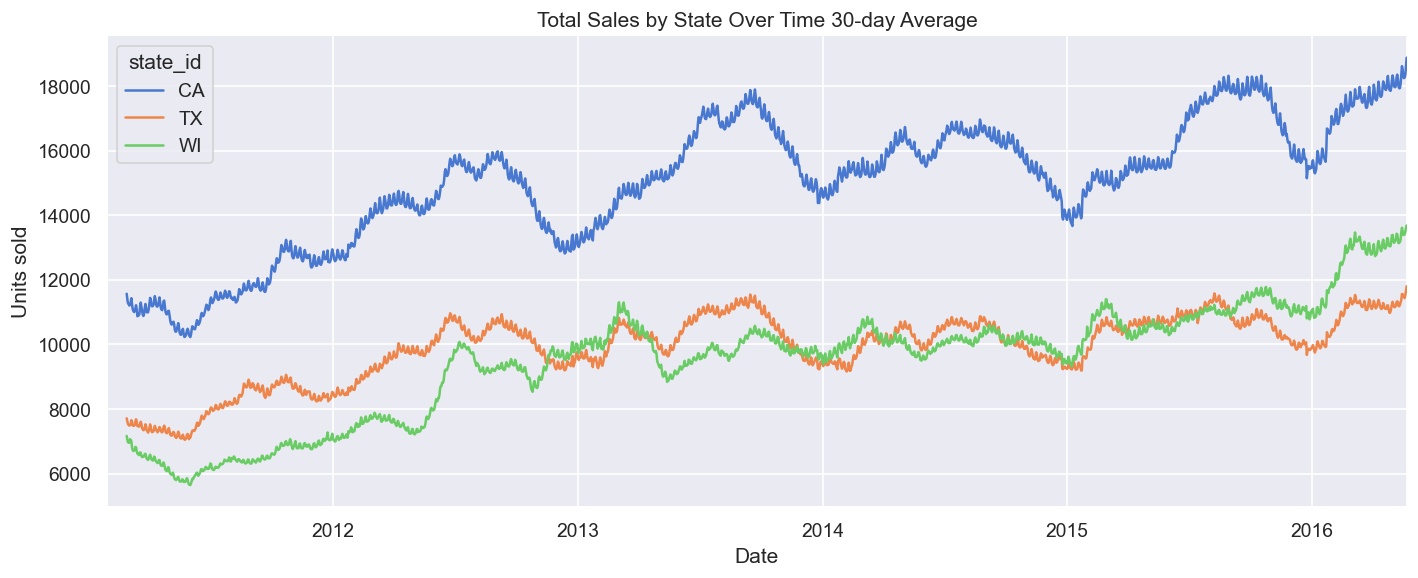

In [22]:
store_sales = (
    merged_df.groupby(['date', 'state_id'])['sales']
    .sum()
    .unstack()
    .rolling(30).mean()   # 30-day rolling avg removes the daily spikes
)

plt.figure(figsize=(12, 5))
store_sales.plot(ax=plt.gca())

plt.title("Total Sales by State Over Time 30-day Average")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()

In [19]:
merged_df['date'] = pd.to_datetime(merged_df['date'])

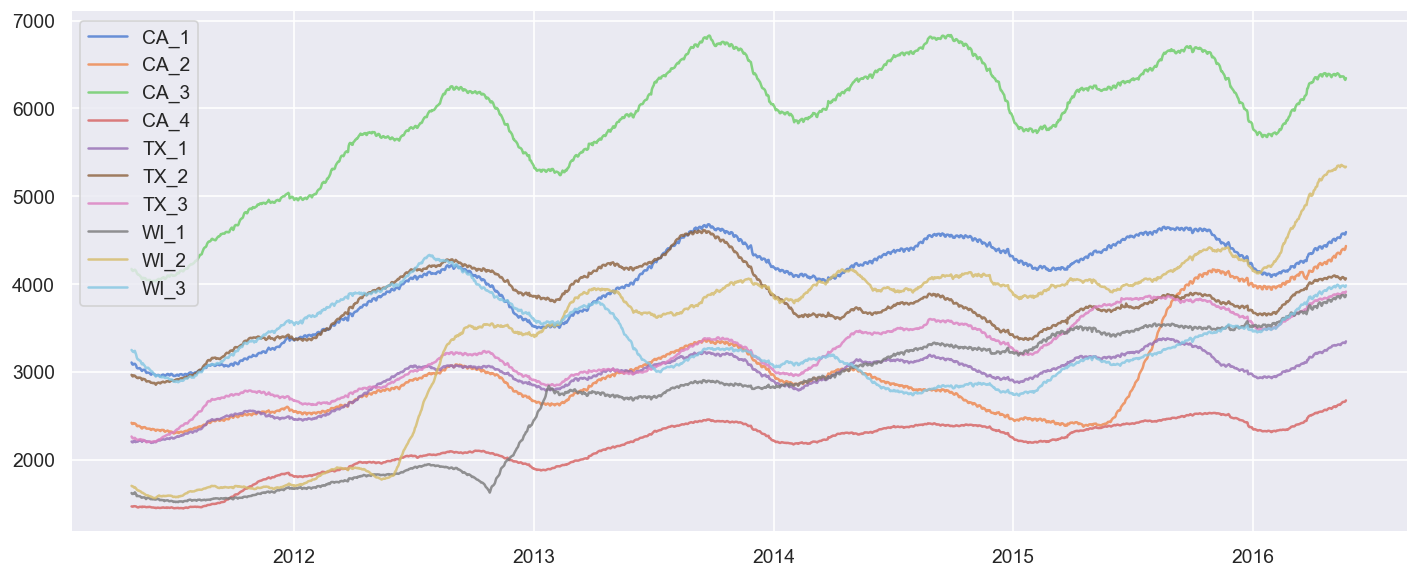

In [20]:
store_list = merged_df['store_id'].unique()
plt.figure(figsize = (12,5))

for store in store_list:
    #filtering rows, grouping by date, summing daily sales
    store_daily = (
        merged_df[merged_df['store_id'] == store]
        .groupby('date')['sales'].sum()
        .sort_index()       # dates in order
        .rolling(90).mean() #90-day rolling average for soothing trend 
    )
    plt.plot(store_daily.index, store_daily.values, alpha = 0.8, label=store)
    
plt.legend(store_list)
plt.tight_layout()
plt.show()

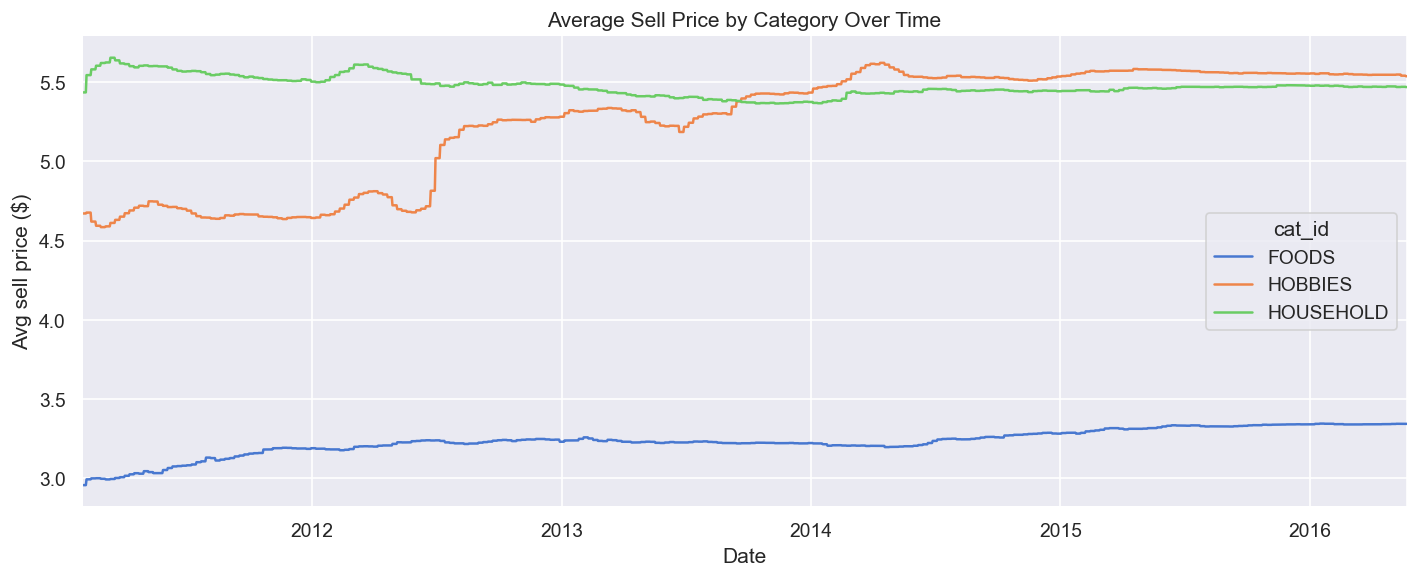

In [21]:
# Mean sell price per date per category
prices_sale = (
    merged_df.groupby(['date', 'cat_id'])['sell_price']
    .mean()
    .unstack()
)
plt.figure(figsize=(12, 5))
prices_sale.plot(ax=plt.gca())

plt.title("Average Sell Price by Category Over Time")
plt.xlabel("Date")
plt.ylabel("Avg sell price ($)")
plt.tight_layout()
plt.show()